# 02 DeepLabV3+ Baseline for Urban Change Detection

This notebook implements a complete DeepLabV3+ baseline for the SYSU-CD style dataset structure.

## Goals
- Load bi-temporal remote sensing images from the predefined `train`, `val`, and `test` folders
- Concatenate `time1` and `time2` into a 6-channel input
- Train a DeepLabV3+ model for binary change detection
- Evaluate the model on the test set using IoU, F1-score, Precision, and Recall
- Export standardized outputs for later group comparison

## Standardized Outputs
This notebook will save the following files under `outputs/deeplabv3plus/`:
- `metrics.csv`
- `training_history.csv`
- `config_used.yaml`
- `shared_test_ids.txt`
- `test_predictions/`
- `sample_visuals/`


In [1]:
# Standard library imports
import os
import sys
import time
import random
from pathlib import Path

# Third-party imports
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Add the project root to Python path
# This allows the notebook to import files from the src/ folder
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

# Import the dataset utility you already created
from src.data_utils import create_dataloader

# Define the config path
config_path = project_root / "configs" / "deeplabv3plus.yaml"

# Load YAML config
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Resolve key paths relative to the project root
data_root = project_root / config["data_root"]
output_dir = project_root / config["output_dir"]
model_save_path = output_dir / config["model_save_name"]

print("Project root:", project_root)
print("Data root:", data_root)
print("Output dir:", output_dir)
print("Model save path:", model_save_path)
print("Loaded config:", config)


Project root: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project
Data root: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/data
Output dir: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/deeplabv3plus
Model save path: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/deeplabv3plus/best_deeplabv3plus.pt
Loaded config: {'model_name': 'deeplabv3plus', 'input_channels': 6, 'num_classes': 1, 'data_root': 'data', 'train_split': 'train', 'val_split': 'val', 'test_split': 'test', 'image_size': 256, 'batch_size': 8, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'patience': 10, 'threshold': 0.5, 'seed': 42, 'optimizer': 'adamw', 'loss_name': 'bce_dice', 'output_dir': 'outputs/deeplabv3plus', 'model_save_name': 'best_deeplabv3plus.pt'}


In [2]:
# Set a fixed random seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config["seed"])

# Select device automatically
# Priority: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else "No MPS backend")

Using device: mps
CUDA available: False
MPS available: True


In [3]:
# Create all required output folders
output_dir.mkdir(parents=True, exist_ok=True)

test_predictions_dir = output_dir / "test_predictions"
sample_visuals_dir = output_dir / "sample_visuals"

test_predictions_dir.mkdir(parents=True, exist_ok=True)
sample_visuals_dir.mkdir(parents=True, exist_ok=True)

print("Created output folders successfully.")

Created output folders successfully.


## Load Dataset Splits

We directly use the predefined `train`, `val`, and `test` folders from the dataset.
This ensures that all models are trained and evaluated on the same split.

In [4]:
# Create dataloaders using the folder-based split structure
train_dataset, train_loader = create_dataloader(
    root_dir=str(data_root),
    split=config["train_split"],
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0
)

val_dataset, val_loader = create_dataloader(
    root_dir=str(data_root),
    split=config["val_split"],
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0
)

test_dataset, test_loader = create_dataloader(
    root_dir=str(data_root),
    split=config["test_split"],
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 12000
Validation samples: 4000
Test samples: 4000


## Create a Shared Formal Subset

To make the comparison fair and reproducible across group members, we use a fixed subset drawn from the official `train`, `val`, and `test` folders.

The subset sizes are:
- Train: 2000 samples
- Validation: 500 samples
- Test: 500 samples

The subset is created with a fixed random seed and saved as text files, so all models use exactly the same sample IDs.


In [5]:
# Shared formal subset settings
FORMAL_SUBSET_SEED = 42

FORMAL_TRAIN_SAMPLES = 2000
FORMAL_VAL_SAMPLES = 500
FORMAL_TEST_SAMPLES = 500

subset_dir = project_root / "data" / "subsets"
subset_dir.mkdir(parents=True, exist_ok=True)

subset_train_file = subset_dir / "subset_train_2000.txt"
subset_val_file = subset_dir / "subset_val_500.txt"
subset_test_file = subset_dir / "subset_test_500.txt"

# Helper function to save sampled IDs
def save_sample_ids(sample_ids, save_path):
    with open(save_path, "w", encoding="utf-8") as f:
        for sample_id in sample_ids:
            f.write(sample_id.replace(".png", "") + "\n")

# Create reproducible subsets from the original folder-based split
rng = random.Random(FORMAL_SUBSET_SEED)

full_train_ids = list(train_dataset.sample_ids)
full_val_ids = list(val_dataset.sample_ids)
full_test_ids = list(test_dataset.sample_ids)

selected_train_ids = sorted(rng.sample(full_train_ids, min(FORMAL_TRAIN_SAMPLES, len(full_train_ids))))
selected_val_ids = sorted(rng.sample(full_val_ids, min(FORMAL_VAL_SAMPLES, len(full_val_ids))))
selected_test_ids = sorted(rng.sample(full_test_ids, min(FORMAL_TEST_SAMPLES, len(full_test_ids))))

save_sample_ids(selected_train_ids, subset_train_file)
save_sample_ids(selected_val_ids, subset_val_file)
save_sample_ids(selected_test_ids, subset_test_file)

print("Saved subset files:")
print(subset_train_file)
print(subset_val_file)
print(subset_test_file)

print("Train subset size:", len(selected_train_ids))
print("Val subset size:", len(selected_val_ids))
print("Test subset size:", len(selected_test_ids))


Saved subset files:
/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/data/subsets/subset_train_2000.txt
/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/data/subsets/subset_val_500.txt
/Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/data/subsets/subset_test_500.txt
Train subset size: 2000
Val subset size: 500
Test subset size: 500


## Filter the Dataset Using Shared Subset Files

Instead of taking the first N samples, we load predefined subset ID files.
This ensures that every model uses the exact same subset.

For the first formal baseline run, we use:
- Train: 2000 samples
- Validation: 500 samples
- Test: 500 samples


In [6]:
# Helper function to load subset IDs from a text file
def load_subset_ids(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        ids = [line.strip() for line in f if line.strip()]
    return ids


# Helper function to convert subset IDs into dataset indices
def get_indices_from_ids(dataset, selected_ids):
    selected_ids_set = set(selected_ids)
    indices = []

    for idx, file_name in enumerate(dataset.sample_ids):
        sample_id = file_name.replace(".png", "")
        if sample_id in selected_ids_set:
            indices.append(idx)

    return indices


# Formal subset settings
USE_FORMAL_SUBSET = True
FORMAL_EPOCHS = 10

if USE_FORMAL_SUBSET:
    train_ids = load_subset_ids(subset_train_file)
    val_ids = load_subset_ids(subset_val_file)
    test_ids = load_subset_ids(subset_test_file)

    train_indices = get_indices_from_ids(train_dataset, train_ids)
    val_indices = get_indices_from_ids(val_dataset, val_ids)
    test_indices = get_indices_from_ids(test_dataset, test_ids)

    train_dataset = torch.utils.data.Subset(train_dataset, train_indices)
    val_dataset = torch.utils.data.Subset(val_dataset, val_indices)
    test_dataset = torch.utils.data.Subset(test_dataset, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=0)

    print("Using shared formal subset mode")
else:
    print("Using full dataset mode")

print("Train samples actually used:", len(train_dataset))
print("Val samples actually used:", len(val_dataset))
print("Test samples actually used:", len(test_dataset))

Using shared formal subset mode
Train samples actually used: 2000
Val samples actually used: 500
Test samples actually used: 500


In [7]:
# Inspect one sample from the training set
sample = train_dataset[0]

print("Sample ID:", sample["id"])
print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)
print("Image dtype:", sample["image"].dtype)
print("Mask dtype:", sample["mask"].dtype)
print("Image min/max:", sample["image"].min().item(), sample["image"].max().item())
print("Mask unique values:", torch.unique(sample["mask"]))

Sample ID: 00006
Image shape: torch.Size([6, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


## Visualize a Sample

The first 3 channels correspond to `time1`, and the last 3 channels correspond to `time2`.
The mask is a binary change map.

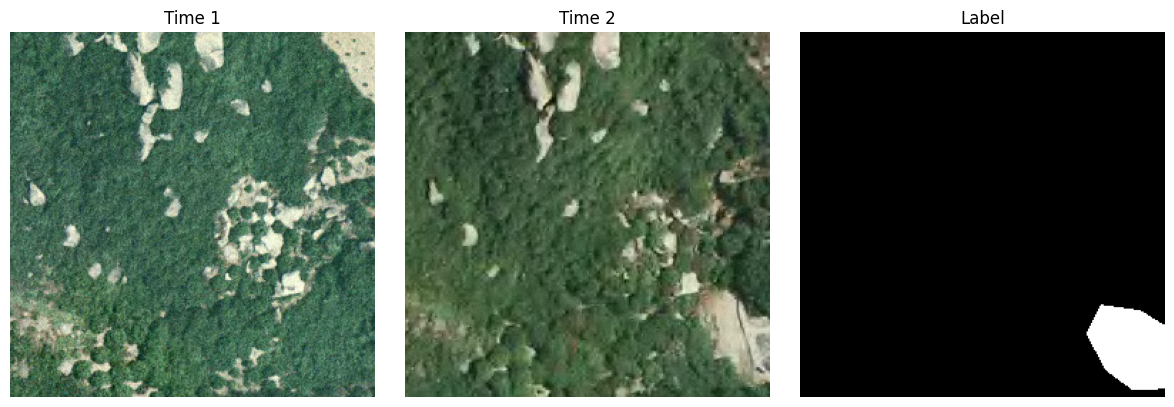

In [8]:
# Visualize one training sample
sample = train_dataset[0]
image = sample["image"].numpy()
mask = sample["mask"].squeeze(0).numpy()

time1_img = image[:3].transpose(1, 2, 0)
time2_img = image[3:].transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(time1_img)
axes[0].set_title("Time 1")
axes[0].axis("off")

axes[1].imshow(time2_img)
axes[1].set_title("Time 2")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Label")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Define the DeepLabV3+ Baseline

We use a lightweight DeepLabV3+ architecture with:
- 6 input channels
- 1 output channel
- backbone, ASPP, and decoder structure
- low-level feature fusion

The output is a pixel-wise binary change map.


In [9]:
# Define the basic building blocks for DeepLabV3+
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dilation=1):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation,
                groups=in_channels,
                bias=False,
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class ASPPPooling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        size = x.shape[-2:]
        pooled = self.pool(x)
        pooled = self.conv(pooled)
        return F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, atrous_rates=(6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ),
            ASPPConv(in_channels, out_channels, atrous_rates[0]),
            ASPPConv(in_channels, out_channels, atrous_rates[1]),
            ASPPConv(in_channels, out_channels, atrous_rates[2]),
            ASPPPooling(in_channels, out_channels),
        ])

        self.project = nn.Sequential(
            nn.Conv2d(out_channels * len(self.branches), out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        features = [branch(x) for branch in self.branches]
        x = torch.cat(features, dim=1)
        return self.project(x)


class SimpleBackbone(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stage1 = nn.Sequential(
            ConvBNReLU(in_channels, 64, stride=2),
            ConvBNReLU(64, 64),
        )
        self.stage2 = nn.Sequential(
            ConvBNReLU(64, 128, stride=2),
            ConvBNReLU(128, 128),
        )
        self.stage3 = nn.Sequential(
            ConvBNReLU(128, 256, stride=2),
            ConvBNReLU(256, 256),
        )
        self.stage4 = nn.Sequential(
            ConvBNReLU(256, 512, stride=2),
            ConvBNReLU(512, 512),
        )

    def forward(self, x):
        x = self.stage1(x)
        low_level = self.stage2(x)
        x = self.stage3(low_level)
        high_level = self.stage4(x)
        return low_level, high_level


class DeepLabV3Plus(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        self.backbone = SimpleBackbone(in_channels=in_channels)
        self.aspp = ASPP(in_channels=512, out_channels=256)

        self.low_level_proj = nn.Sequential(
            nn.Conv2d(128, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            DepthwiseSeparableConv(256 + 48, 256),
            DepthwiseSeparableConv(256, 256),
        )

        self.classifier = nn.Conv2d(256, out_channels, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        low_level, high_level = self.backbone(x)

        x = self.aspp(high_level)
        x = F.interpolate(x, size=low_level.shape[-2:], mode="bilinear", align_corners=False)

        low_level = self.low_level_proj(low_level)
        x = torch.cat([x, low_level], dim=1)

        x = self.decoder(x)
        logits = self.classifier(x)
        logits = F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)
        return logits


In [10]:
# Build the model and test one forward pass
model = DeepLabV3Plus(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

sample_batch = next(iter(train_loader))
images = sample_batch["image"].to(device)

with torch.no_grad():
    logits = model(images)

print("Input batch shape:", images.shape)
print("Output logits shape:", logits.shape)


Input batch shape: torch.Size([8, 6, 256, 256])
Output logits shape: torch.Size([8, 1, 256, 256])


## Define Loss and Evaluation Metrics

The main training loss is the combination of:
- Binary Cross-Entropy (BCE)
- Dice Loss

The evaluation metrics are:
- IoU
- F1-score
- Precision
- Recall

In [11]:
# Define Dice loss
def dice_loss(logits, targets, eps=1e-8):
    probs = torch.sigmoid(logits)
    probs = probs.view(-1)
    targets = targets.view(-1)

    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice


# Define the combined BCE + Dice loss
def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dloss = dice_loss(logits, targets)
    return bce + dloss


# Convert logits into binary predictions
def binarize_predictions(logits, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return preds


# Compute confusion matrix counts
def compute_confusion_counts(preds, targets):
    preds = preds.view(-1)
    targets = targets.view(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    return tp, fp, fn, tn


# Compute final metrics from confusion counts
def compute_metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }

In [12]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    total_batches = len(loader)

    for batch_idx, batch in enumerate(loader, start=1):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = bce_dice_loss(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Print lightweight progress updates during training
        if batch_idx % 50 == 0 or batch_idx == total_batches:
            print(
                f"  Training batch {batch_idx}/{total_batches} "
                f"| Current batch loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


# Validate the model for one epoch
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()
    running_loss = 0.0

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            logits = model(images)
            loss = bce_dice_loss(logits, masks)

            running_loss += loss.item() * images.size(0)

            preds = binarize_predictions(logits, threshold=threshold)
            tp, fp, fn, tn = compute_confusion_counts(preds, masks)

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics_from_counts(total_tp, total_fp, total_fn, total_tn)

    return epoch_loss, metrics

In [13]:
# Save the exact config used for this run
with open(output_dir / "config_used.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=False)

# Define model save path
model_save_path = output_dir / config["model_save_name"]

# Build model again to make sure the training starts from a clean state
model = DeepLabV3Plus(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

# Define optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

# Initialize training trackers
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

history = []

print("Model save path:", model_save_path)


Model save path: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/deeplabv3plus/best_deeplabv3plus.pt


## Training Loop

We train the DeepLabV3+ model with early stopping based on validation loss.
The best model checkpoint is saved automatically.


In [14]:
# Decide how many epochs to run for the formal baseline subset
num_epochs_to_run = FORMAL_EPOCHS if USE_FORMAL_SUBSET else config["num_epochs"]
print("Number of epochs to run:", num_epochs_to_run)

Number of epochs to run: 10


In [15]:
# Run the training loop for the formal subset version
for epoch in range(1, num_epochs_to_run + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        device,
        threshold=config["threshold"]
    )

    record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_iou": val_metrics["iou"]
    }
    history.append(record)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    # Save the best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved best model at epoch {epoch}")
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= config["patience"]:
        print(f"Early stopping triggered at epoch {epoch}")
        break

print("Training finished.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

  Training batch 50/250 | Current batch loss: 0.9385
  Training batch 100/250 | Current batch loss: 0.7256
  Training batch 150/250 | Current batch loss: 0.9216
  Training batch 200/250 | Current batch loss: 1.0878
  Training batch 250/250 | Current batch loss: 0.6987
Epoch 001 | Train Loss: 0.9323 | Val Loss: 0.8432 | Val IoU: 0.4338 | Val F1: 0.6051
Saved best model at epoch 1
  Training batch 50/250 | Current batch loss: 0.6718
  Training batch 100/250 | Current batch loss: 0.6339
  Training batch 150/250 | Current batch loss: 0.6285
  Training batch 200/250 | Current batch loss: 0.8196
  Training batch 250/250 | Current batch loss: 0.9243
Epoch 002 | Train Loss: 0.7300 | Val Loss: 0.9649 | Val IoU: 0.4634 | Val F1: 0.6333
  Training batch 50/250 | Current batch loss: 0.5813
  Training batch 100/250 | Current batch loss: 0.7559
  Training batch 150/250 | Current batch loss: 0.8688
  Training batch 200/250 | Current batch loss: 0.5059
  Training batch 250/250 | Current batch loss: 0.

In [16]:
# Save training history as CSV
history_df = pd.DataFrame(history)
history_df.to_csv(output_dir / "training_history.csv", index=False)

print(history_df.head())

   epoch  train_loss  val_loss  val_precision  val_recall    val_f1   val_iou
0      1    0.932338  0.843166       0.663110    0.556437  0.605108  0.433803
1      2    0.730009  0.964926       0.522896    0.802720  0.633274  0.463351
2      3    0.691349  0.840509       0.560388    0.771338  0.649155  0.480555
3      4    0.661342  0.751134       0.632463    0.708172  0.668180  0.501705
4      5    0.663865  0.758865       0.639258    0.692031  0.664599  0.497677


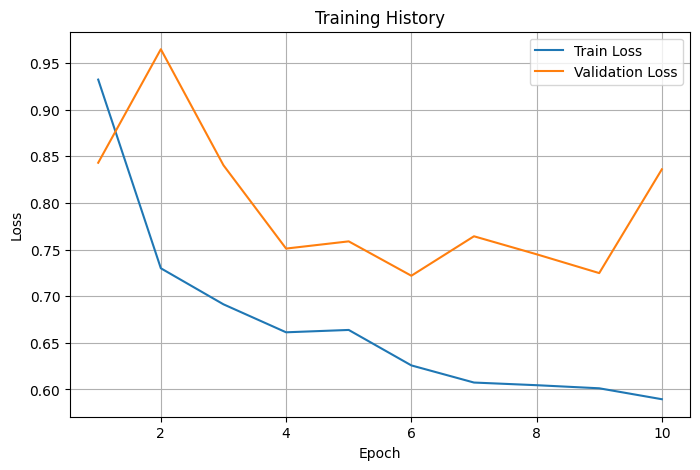

In [17]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

## Final Test Evaluation

After training, we load the best checkpoint and evaluate the model on the test set.
The final outputs include:
- IoU
- F1-score
- Precision
- Recall
- parameter count
- inference time

In [18]:
# Load the best checkpoint before test evaluation
best_model = DeepLabV3Plus(
    in_channels=config["input_channels"],
    out_channels=config["num_classes"]
).to(device)

best_model.load_state_dict(torch.load(model_save_path, map_location=device))
best_model.eval()

print("Loaded best model successfully.")


Loaded best model successfully.


In [19]:
# Evaluate on the test set
total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
total_inference_time = 0.0
total_images = 0

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        start_time = time.perf_counter()
        logits = best_model(images)
        end_time = time.perf_counter()

        total_inference_time += (end_time - start_time)
        total_images += images.size(0)

        preds = binarize_predictions(logits, threshold=config["threshold"])
        tp, fp, fn, tn = compute_confusion_counts(preds, masks)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

test_metrics = compute_metrics_from_counts(total_tp, total_fp, total_fn, total_tn)

# Compute parameter count and average inference time
param_count = sum(p.numel() for p in best_model.parameters())
param_count_million = param_count / 1e6
avg_inference_time_ms = (total_inference_time / total_images) * 1000

print("Test metrics:", test_metrics)
print("Parameter count (M):", param_count_million)
print("Average inference time per image (ms):", avg_inference_time_ms)

Test metrics: {'precision': 0.7847534161045885, 'recall': 0.7175396315127217, 'f1': 0.74964291975511, 'iou': 0.5995430741992477}
Parameter count (M): 8.977905
Average inference time per image (ms): 0.5283310740012439


In [20]:
# Save final test metrics as a one-row CSV file
metrics_df = pd.DataFrame([{
    "model": config["model_name"],
    "iou": test_metrics["iou"],
    "f1": test_metrics["f1"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "params_m": param_count_million,
    "inference_time_ms": avg_inference_time_ms
}])

metrics_df.to_csv(output_dir / "metrics.csv", index=False)
metrics_df.head()

,model,iou,f1,precision,recall,params_m,inference_time_ms
0,deeplabv3plus,0.599543,0.749643,0.784753,0.71754,8.977905,0.528331


In [21]:
# Save shared test IDs for later comparison
shared_test_ids = []

for i in range(min(20, len(test_dataset))):
    sample = test_dataset[i]
    shared_test_ids.append(sample["id"])

with open(output_dir / "shared_test_ids.txt", "w", encoding="utf-8") as f:
    for sample_id in shared_test_ids:
        f.write(sample_id + "\n")

print("Saved shared test IDs:")
print(shared_test_ids[:10])

Saved shared test IDs:
['00012', '00014', '00021', '00027', '00037', '00046', '00057', '00064', '00089', '00093']


In [22]:
# Save predictions and visualizations for the first few test samples
best_model.eval()

num_visual_samples = min(20, len(test_dataset))

for i in range(num_visual_samples):
    sample = test_dataset[i]

    image = sample["image"].unsqueeze(0).to(device)
    mask = sample["mask"].squeeze(0).numpy()
    sample_id = sample["id"]

    with torch.no_grad():
        logits = best_model(image)
        pred = binarize_predictions(logits, threshold=config["threshold"])

    pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8) * 255

    # Save raw predicted mask
    pred_img = Image.fromarray(pred_mask)
    pred_img.save(test_predictions_dir / f"{sample_id}_pred.png")

    # Prepare visualization
    image_np = sample["image"].numpy()
    time1_img = image_np[:3].transpose(1, 2, 0)
    time2_img = image_np[3:].transpose(1, 2, 0)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(time1_img)
    axes[0].set_title("Time 1")
    axes[0].axis("off")

    axes[1].imshow(time2_img)
    axes[1].set_title("Time 2")
    axes[1].axis("off")

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")

    axes[3].imshow(pred_mask, cmap="gray")
    axes[3].set_title("Prediction")
    axes[3].axis("off")

    plt.tight_layout()
    plt.savefig(sample_visuals_dir / f"{sample_id}_visual.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved predictions and sample visuals successfully.")

Saved predictions and sample visuals successfully.


Number of saved visualizations: 20


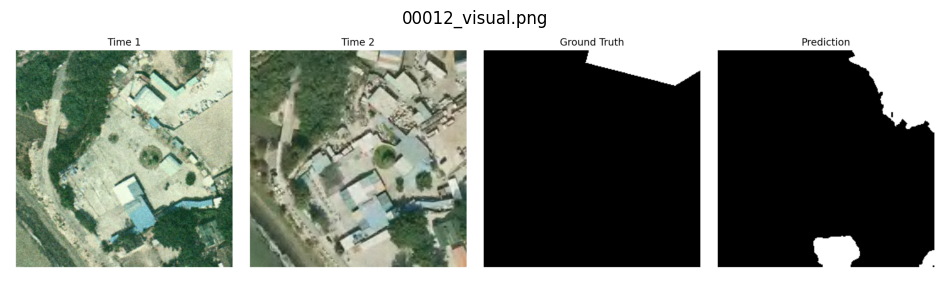

In [23]:
# Preview one saved visualization
saved_visuals = sorted(sample_visuals_dir.glob("*.png"))

print("Number of saved visualizations:", len(saved_visuals))

if len(saved_visuals) > 0:
    preview_img = Image.open(saved_visuals[0])
    plt.figure(figsize=(12, 4))
    plt.imshow(preview_img)
    plt.axis("off")
    plt.title(saved_visuals[0].name)
    plt.show()

## Summary

This notebook completed the full DeepLabV3+ baseline workflow:
- Loaded the predefined dataset split
- Built 6-channel inputs from bi-temporal imagery
- Trained a DeepLabV3+ model with BCE + Dice loss
- Evaluated the model on the test set
- Saved standardized outputs for later model comparison

The exported files under `outputs/deeplabv3plus/` can now be reused by:
- `04_comparison.ipynb`
- `05_error_analysis.ipynb`
- `06_prediction.ipynb`


In [24]:
# Display all key output files
print("Output directory:", output_dir)
print()

for path in sorted(output_dir.rglob("*")):
    print(path.relative_to(project_root))

Output directory: /Users/guiyanmin/Desktop/GU/Course/DSAN-6600/Final_project/DSAN6600-final-project/outputs/deeplabv3plus

outputs/deeplabv3plus/.DS_Store
outputs/deeplabv3plus/best_deeplabv3plus.pt
outputs/deeplabv3plus/config_used.yaml
outputs/deeplabv3plus/metrics.csv
outputs/deeplabv3plus/sample_visuals
outputs/deeplabv3plus/sample_visuals/00012_visual.png
outputs/deeplabv3plus/sample_visuals/00014_visual.png
outputs/deeplabv3plus/sample_visuals/00021_visual.png
outputs/deeplabv3plus/sample_visuals/00027_visual.png
outputs/deeplabv3plus/sample_visuals/00037_visual.png
outputs/deeplabv3plus/sample_visuals/00046_visual.png
outputs/deeplabv3plus/sample_visuals/00057_visual.png
outputs/deeplabv3plus/sample_visuals/00064_visual.png
outputs/deeplabv3plus/sample_visuals/00089_visual.png
outputs/deeplabv3plus/sample_visuals/00093_visual.png
outputs/deeplabv3plus/sample_visuals/00129_visual.png
outputs/deeplabv3plus/sample_visuals/00131_visual.png
outputs/deeplabv3plus/sample_visuals/00137_